<a href="https://colab.research.google.com/github/Ambos14/KISysteme26/blob/main/block_1/Aufgabe_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Matrix multiplication in Numba


We consider the problem of evaluating the matrix multiplication $C = A\times B$ for matrices $A, B\in\mathbb{R}^{n\times n}$.
A simple Python implementation of the matrix-matrix product is given below through the function `matrix_product`. At the end this
function is checked against the Numpy implementation of the matrix-matrix product.

In [3]:
import numpy as np

def matrix_product(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c

a = np.random.randn(10, 10)
b = np.random.randn(10, 10)

c_actual = matrix_product(a, b)
c_expected = a @ b

error = np.linalg.norm(c_actual - c_expected) / np.linalg.norm(c_expected)
print(f"The error is {error}.")


The error is 1.2020691871637667e-16.


The matrix product is one of the most fundamental operations on modern computers. Most algorithms eventually make use of this operation. A lot of effort is therefore spent on optimising the matrix product. Vendors provide hardware optimised BLAS (Basis Linear Algebra Subroutines) that provide highly efficient versions of the matrix product. Alternatively, open-source libraries sucha as Openblas provide widely used generic open-source implementations of this operation.

In this assignment we want to learn at the example of matrix-matrix products about the possible speedups offered by Numba, and the effects of cache-efficient programming.

## 1.1 Benchmark
Benchmark the above function against the Numpy dot product for matrix sizes up to 1000. Plot the timing results of the above function against the timing results for the Numpy dot product. You need not benchmark every dimension up to 1000. Figure out what dimensions to use so that you can represent the result without spending too much time waiting for the code to finish. To perform benchmarks you can use the `%timeit` magic command. An example is

    ```
    timeit_result = %timeit -o matrix_product(a, b)
    print(timeit_result.best)
    ```

## 1.2 Optimize
Now optimise the code by using Numba to JIT-compile it. Also, there is lots of scope for parallelisation in the code. You can for example parallelize the outer-most for-loop. Benchmark the JIT-compiled serial code against the JIT-compiled parallel code. Comment on the expected performance on your system against the observed performance.

## 1.3 (Optional) Cache Optimization
Now let us improve Cache efficiency. Notice that in the matrix $B$ we traverse by columns. However, the default storage ordering in Numpy is row-based. Hence, the expression `mat_b[k, col_ind]` jumps in memory by `n` units if we move from $k$ to $k+1$. Run your parallelized JIT-compiled Numba code again. But this time choose a matrix $B$ that is stored in column-major order. To change an array to column major order you can use the command `np.asfortranarray`.






In [2]:
# 1.1 Benchmark



In [ ]:
import numpy as np

def matrix_product(mat_a, mat_b):
    """Returns the product of the matrices mat_a and mat_b."""
    m = mat_a.shape[0]
    n = mat_b.shape[1]

    assert(mat_a.shape[1] == mat_b.shape[0])

    ncol = mat_a.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += mat_a[row_ind, k] * mat_b[k, col_ind]

    return mat_c

a = np.random.randn(10, 10)
b = np.random.randn(10, 10)

c_actual = matrix_product(a, b)
c_expected = a @ b

error = np.linalg.norm(c_actual - c_expected) / np.linalg.norm(c_expected)
print(f"The error is {error}.")


The error is 1.2020691871637667e-16.


In [9]:
import numpy as np

# 1. Vorbereitung: Dimensionen festlegen
# Wir nutzen die vorab besprochenen sinnvollen Testgrößen
dimensions = [2, 10, 50, 100, 200, 500, 1000]
results_python = []
results_numpy = []

# Generator für Zufallszahlen (Best Practice)
rng = np.random.default_rng(seed=42)

print("Starte Benchmark...")

for n in dimensions:
    # A. Matrizen dynamisch für die aktuelle Dimension n erstellen
    mat_a = rng.random((n, n))
    mat_b = rng.random((n, n))

    print(f"Messe Dimension {n}x{n}...")

    # B. Benchmark für deine eigene Funktion
    # -o speichert das Ergebnis, -q unterdrückt die Textausgabe im Terminal
    t_custom = %timeit -o -q -n 1 -r 1 matrix_product(mat_a, mat_b)
    results_python.append(t_custom.best)

    # C. Benchmark für NumPy (Referenzwert)
    t_numpy = %timeit -o -q np.dot(mat_a, mat_b)
    results_numpy.append(t_numpy.best)

print("Benchmark abgeschlossen!")
print(f"Gefundene Zeiten (Python): {results_python}")

Starte Benchmark...
Messe Dimension 2x2...
Messe Dimension 10x10...
Messe Dimension 50x50...
Messe Dimension 100x100...
Messe Dimension 200x200...
Messe Dimension 500x500...
Messe Dimension 1000x1000...
Benchmark abgeschlossen!
Gefundene Zeiten (Python): [3.3494000035716454e-05, 0.0014612929999202606, 0.15651720599998953, 0.6758383470000808, 6.9956140340000275, 96.32298902599996, 773.787914128]


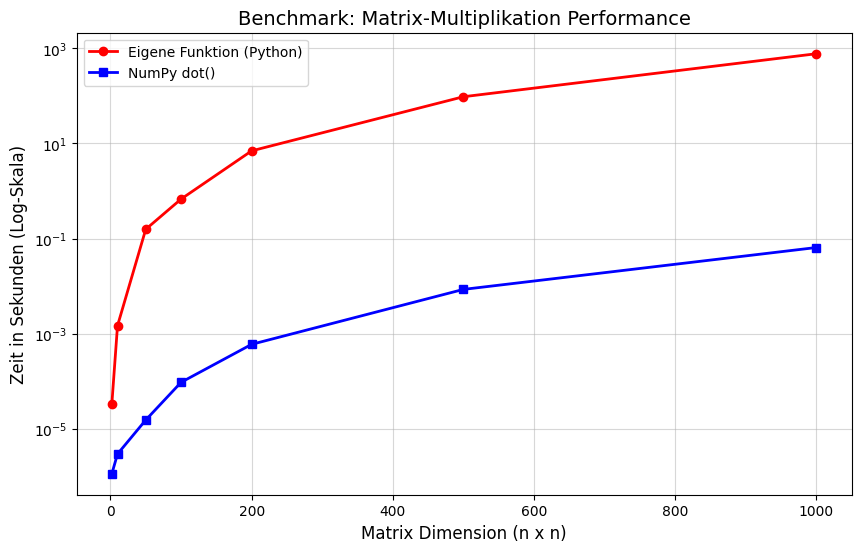

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Using the actual benchmark data from the previous cell
dimensions = [2, 10, 50, 100, 200, 500, 1000]
times_python = results_python # Use the actual results from the benchmarking cell
times_numpy = results_numpy # Use the actual results from the benchmarking cell

plt.figure(figsize=(10, 6))

# 1. Daten plotten
plt.plot(dimensions, times_python, 'o-', label='Eigene Funktion (Python)', color='red', linewidth=2)
plt.plot(dimensions, times_numpy, 's-', label='NumPy dot()', color='blue', linewidth=2)

# 2. Logarithmische Skalierung (Wichtig für den Vergleich!)
plt.yscale('log')

# 3. Beschriftungen und Design
plt.title('Benchmark: Matrix-Multiplikation Performance', fontsize=14)
plt.xlabel('Matrix Dimension (n x n)', fontsize=12)
plt.ylabel('Zeit in Sekunden (Log-Skala)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5) # Gitter für bessere Lesbarkeit
plt.legend()

# 4. Anzeigen
plt.show()

In [15]:
import numpy as np
from numba import njit, prange

# --- 1. JIT Serial ---
@njit
def matrix_product_jit(A, B):
    """Returns the product of the matrices A and B (Numba JIT serial version)."""
    m = A.shape[0]
    n = B.shape[1]

    assert(A.shape[1] == B.shape[0])

    ncol = A.shape[1]

    mat_c = np.zeros((m, n), dtype=np.float64)

    for row_ind in range(m):
        for col_ind in range(n):
            for k in range(ncol):
                mat_c[row_ind, col_ind] += A[row_ind, k] * B[k, col_ind]

    return mat_c

# --- 2. JIT Parallel ---
@njit(parallel=True)
def matrix_product_parallel(A, B):
   """Returns the product of the matrices A and B (Numba JIT parallel version)."""
   m = A.shape[0]
   n = B.shape[1]

   assert(A.shape[1] == B.shape[0])

   ncol = A.shape[1]

   mat_c = np.zeros((m, n), dtype=np.float64)

   for row_ind in prange(m): # Use prange for parallelization
       for col_ind in range(n):
           for k in range(ncol):
               mat_c[row_ind, col_ind] += A[row_ind, k] * B[k, col_ind]

   return mat_c

# --- 3. Benchmarking ---
# WICHTIG: Einmal "Warm-up" für beide Funktionen,
# damit die Kompilierzeit nicht das Ergebnis verfälscht!
_ = matrix_product_jit(np.zeros((2,2)), np.zeros((2,2)))
_ = matrix_product_parallel(np.zeros((2,2)), np.zeros((2,2)))

# Danach: Messungen mit %timeit wie gehabt

# 1. Vorbereitung: Dimensionen festlegen
dimensions = [2, 10, 50, 100, 200, 500, 1000]
results_numba_serial = []
results_numba_parallel = []

# Generator für Zufallszahlen (Best Practice)
rng = np.random.default_rng(seed=42)

print("Starte Benchmark für Numba Funktionen...")

for n in dimensions:
    # A. Matrizen dynamisch für die aktuelle Dimension n erstellen
    mat_a = rng.random((n, n))
    mat_b = rng.random((n, n))

    print(f"Messe Dimension {n}x{n}...")

    # B. Benchmark für Numba JIT Serial
    t_numba_serial = %timeit -o -q -n 1 -r 1 matrix_product_jit(mat_a, mat_b)
    results_numba_serial.append(t_numba_serial.best)

    # C. Benchmark für Numba JIT Parallel
    t_numba_parallel = %timeit -o -q -n 1 -r 1 matrix_product_parallel(mat_a, mat_b)
    results_numba_parallel.append(t_numba_parallel.best)

print("Numba Benchmark abgeschlossen!")
print(f"Gefundene Zeiten (Numba Serial): {results_numba_serial}")
print(f"Gefundene Zeiten (Numba Parallel): {results_numba_parallel}")

Starte Benchmark für Numba Funktionen...
Messe Dimension 2x2...
Messe Dimension 10x10...
Messe Dimension 50x50...
Messe Dimension 100x100...
Messe Dimension 200x200...
Messe Dimension 500x500...
Messe Dimension 1000x1000...
Numba Benchmark abgeschlossen!
Gefundene Zeiten (Numba Serial): [1.7776999811758287e-05, 2.141900040442124e-05, 0.0001538400001663831, 0.0013601950004158425, 0.011558422999769391, 0.20724064400019415, 2.22213327100053]
Gefundene Zeiten (Numba Parallel): [0.00042550599937385414, 8.805499965092167e-05, 0.00023103200055629713, 0.0008352810000360478, 0.006514239000352973, 0.15854884700002003, 1.2956806060001327]


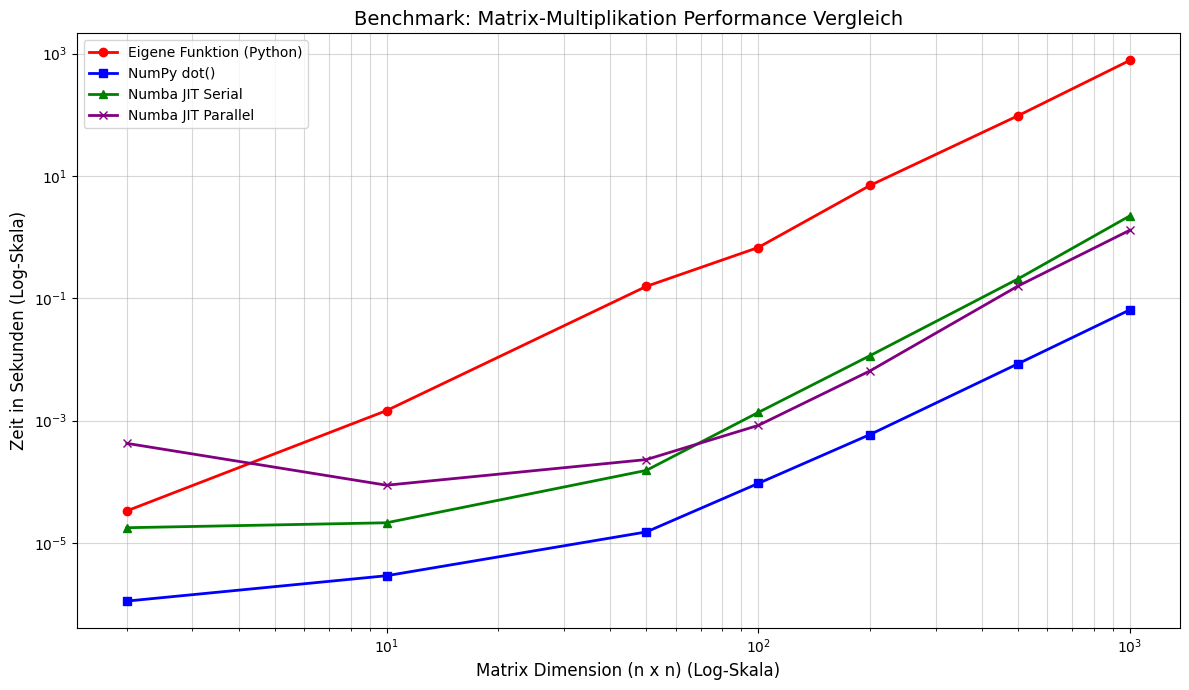

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Using the actual benchmark data from the previous cell
dimensions = [2, 10, 50, 100, 200, 500, 1000]
times_python = results_python # Python custom function results
times_numpy = results_numpy # NumPy dot() results
times_numba_serial = results_numba_serial # Numba JIT serial results
times_numba_parallel = results_numba_parallel # Numba JIT parallel results

plt.figure(figsize=(12, 7))

# 1. Daten plotten
plt.plot(dimensions, times_python, 'o-', label='Eigene Funktion (Python)', color='red', linewidth=2)
plt.plot(dimensions, times_numpy, 's-', label='NumPy dot()', color='blue', linewidth=2)
plt.plot(dimensions, times_numba_serial, '^-', label='Numba JIT Serial', color='green', linewidth=2)
plt.plot(dimensions, times_numba_parallel, 'x-', label='Numba JIT Parallel', color='purple', linewidth=2)

# 2. Logarithmische Skalierung (Wichtig für den Vergleich!)
plt.yscale('log')
plt.xscale('log') # Add log scale for x-axis as well for better visualization of different scales

# 3. Beschriftungen und Design
plt.title('Benchmark: Matrix-Multiplikation Performance Vergleich', fontsize=14)
plt.xlabel('Matrix Dimension (n x n) (Log-Skala)', fontsize=12)
plt.ylabel('Zeit in Sekunden (Log-Skala)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5) # Gitter für bessere Lesbarkeit
plt.legend()

# 4. Anzeigen
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()